In [1]:
# --- environment -------------------------------------------------------------
# Pin ONE GPU *before* jax is imported: a 2-GPU numpyro run can stall at 100% on
# Oscar (NCCL), and XLA otherwise pre-allocates 75% of the card up front.
import os

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "1")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import logging
import time
import warnings
from dataclasses import replace

warnings.filterwarnings("ignore")
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

import arviz as az
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import hssm
from hssm.addm import aDDM
from hssm.addm.config import aDDMConfig

hssm.set_floatX("float64")

# --- compat shims for this checkout ------------------------------------------
# (1) HSSM injects nuts_sampler_kwargs={"jitter": False} for the numpyro backend,
#     but pymc 6.2 forwards that dict verbatim to numpyro's NUTS, which has no
#     `jitter` argument.  Swallow it.
import numpyro.infer as _npi

if not getattr(_npi.NUTS.__init__, "_shim", False):
    _orig_nuts_init = _npi.NUTS.__init__

    def _nuts_init(self, *args, jitter=None, **kwargs):
        _orig_nuts_init(self, *args, **kwargs)

    _nuts_init._shim = True
    _npi.NUTS.__init__ = _nuts_init

# (2) HSSM._clean_posterior_group does `idata["posterior"][list_of_names]`, which
#     xarray 2026.7's DataTree no longer allows.  Route it through `.dataset`.
from hssm.base import HSSMBase


def _clean_posterior_group(self, idata=None):
    if idata is None or "posterior" not in idata:
        return
    post = idata["posterior"].dataset
    deterministics = {v.name for v in self.pymc_model.deterministics}
    drop = {k for k in self.model.distributional_components if k in deterministics}
    keep = [v for v in post.data_vars if v not in drop and "_mean" not in str(v)]
    idata["posterior"] = xr.DataTree(post[keep])


HSSMBase._clean_posterior_group = _clean_posterior_group


# --- small helpers -----------------------------------------------------------
def fig(pc):
    """arviz >= 1.0 returns a PlotCollection; pull the matplotlib Figure out."""
    return pc.viz.dataset["figure"].item()


def posterior(idata):
    """The posterior group of an HSSM idata as a plain xarray Dataset."""
    post = idata["posterior"]
    return post.dataset if hasattr(post, "dataset") else post


def as_tree(ds):
    """Wrap a Dataset of posterior draws so arviz treats it as a model."""
    return xr.DataTree.from_dict({"posterior": ds})


print("hssm", hssm.__version__, "| arviz", az.__version__)

Setting PyTensor floatX type to float64.
Setting "jax_enable_x64" to True. If this is not intended, please set `jax` to False.
hssm 0.4.0 | arviz 1.2.0


In [2]:
monk_data_1 = pd.read_csv("/users/azhan378/data/azhang/addm_hssm_paper_code/monkey_data/behav_table_1.csv")
monk_data_1.sort_values(by='trialNum', ascending=True, inplace=True)

monk_data_2 = pd.read_csv("/users/azhan378/data/azhang/addm_hssm_paper_code/monkey_data/behav_table_2.csv")
monk_data_2.sort_values(by='trialNum', ascending=True, inplace=True)

monk_data_3 = pd.read_csv("/users/azhan378/data/azhang/addm_hssm_paper_code/monkey_data/behav_table_3.csv")
monk_data_3.sort_values(by='trialNum', ascending=True, inplace=True)
monk_data_1

,trialNum,lVal,rVal,firstVal,secondVal,chosenVal,leftChosen,firstChosen,liftRT,reachRT,firstIsLeft,firstIsRight,secondIsLeft,secondIsRight,firstFixLat,secondFixLat,thirdFixLat,firstFixDur,secondFixDur,thirdFixDur
308,1,3,1,3,1,1,0,0,0.757170,0.172254,1,0,0,1,0.162,0.410,NaN,0.188,0.644,NaN
412,2,4,3,4,3,4,1,1,0.747137,0.150739,1,0,0,1,0.168,0.420,0.636,0.192,0.156,0.576
153,3,2,4,2,4,4,0,0,0.747201,0.151524,1,0,0,1,0.134,0.402,NaN,0.212,0.916,NaN
361,4,3,3,3,3,3,1,1,0.947236,0.141216,1,0,0,1,0.158,0.386,0.758,0.176,0.328,0.688
525,5,5,5,5,5,5,0,1,1.076900,0.164868,0,1,1,0,0.142,0.370,0.882,0.188,0.456,0.656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,583,4,2,2,4,4,1,0,0.777188,0.174139,0,1,1,0,0.171,0.423,NaN,0.208,0.656,NaN
306,584,4,3,3,4,4,1,0,0.877214,0.154446,0,1,1,0,0.173,0.401,NaN,0.184,0.780,NaN
411,585,2,3,3,2,3,0,1,1.027219,0.175890,0,1,1,0,0.117,0.405,0.765,0.228,0.316,0.552
307,586,3,4,3,4,4,0,0,0.867116,0.176373,1,0,0,1,0.149,0.417,NaN,0.220,1.048,NaN


# aDDM vs. TADA on the monkey data

Two likelihoods for the same gaze-dependent decision process, fit to the same
587 trials:

* **aDDM (exact)** — `hssm.aDDM`, the gaze-conditioned first-passage-time
  likelihood evaluated on each trial's observed fixation sequence.
* **TADA** — the *time-averaged drift approximation*
  ([arXiv:2512.10250](https://arxiv.org/abs/2512.10250), §8 of HSSM's
  `attentional_ddm.ipynb`): replace the time-varying drift with its
  gaze-weighted temporal average and feed that one constant drift to a
  **standard DDM**.

---

## 1. Building the model frame

Both models are built from one frame, so the *only* thing that differs between
them is the likelihood.

Conventions, matching HSSM's aDDM kernel:

| quantity | convention |
|---|---|
| item 1 | **left** (`r1 = lVal`); item 2 is right (`r2 = rVal`) |
| `response` | `+1` = upper bound = item 1 (left) chosen |
| `flag` | `0` if the first fixation is on item 1 (left), else `1`; stage `j` fixates item 1 iff `j % 2 == flag` |
| clock origin | the **first fixation onset** (`firstFixLat`), so `sacc_array[0] = 0` |

### The 100 ms truncation

The original analysis assumes the decision has already terminated 100 ms before
the hand leaves the key — the final fixation is truncated at `liftRT - 0.100`:

```
rt          = (liftRT - 0.100) - firstFixLat
sacc_array  = [0, secondFixLat - firstFixLat, thirdFixLat - firstFixLat]
d           = how many of those onsets fall strictly before rt
```

Two consequences:

1. a fixation whose onset lands inside the truncated 100 ms window is **not**
   part of the decision, so it is dropped and that trial's `d` shrinks;
2. there is **no non-decision time left to estimate** — the 100 ms motor delay
   and the pre-first-fixation latency are both already removed from `rt`. Every
   model below is therefore fit with `t` **fixed at 0**.

In [3]:
MOTOR_DELAY = 0.100  # s -- the decision terminates this long before liftRT


def prepare_monkey_data(behav, motor_delay=MOTOR_DELAY):
    """Monkey behaviour table -> the aDDM frame (conventions in the cell above)."""
    b = behav.sort_values("trialNum").reset_index(drop=True)

    t0 = b["firstFixLat"].to_numpy(float)                    # clock origin
    rt = (b["liftRT"].to_numpy(float) - motor_delay) - t0    # decision time

    # fixation onsets, re-referenced to the first fixation
    onsets = np.column_stack(
        [t0, b["secondFixLat"].to_numpy(float), b["thirdFixLat"].to_numpy(float)]
    ) - t0[:, None]
    onsets[:, 0] = 0.0

    # *** the truncation ***  only fixations that begin before the (already
    # truncated) decision time are part of the accumulation; the rest are gone,
    # and d shrinks with them.
    keep = np.isfinite(onsets) & (onsets < rt[:, None])
    keep[:, 0] = True
    sacc = np.where(keep, onsets, 0.0)                       # zero-pad past d

    out = pd.DataFrame(
        {
            "rt": rt,
            "response": np.where(b["leftChosen"].to_numpy(int) == 1, 1.0, -1.0),
            "r1": b["lVal"].to_numpy(float),                 # left  = item 1
            "r2": b["rVal"].to_numpy(float),                 # right = item 2
            "flag": np.where(b["firstIsLeft"].to_numpy(int) == 1, 0, 1).astype(int),
            "d": keep.sum(1).astype(int),
            "sigma": 1.0,
        }
    )
    out["sacc_array"] = pd.Series([tuple(row) for row in sacc], index=out.index)
    return out


def gaze_fraction_item1(df):
    """Fraction of each trial's decision time spent fixating item 1 (left).

    Stage j runs from sacc[j] to sacc[j+1], the last stage runs to rt, and stage j
    is on item 1 iff j % 2 == flag -- the same weighting TADA's `get_mu_tada` uses.
    """
    sacc = np.stack([np.asarray(s, float) for s in df["sacc_array"]])
    rt = df["rt"].to_numpy(float)
    d = df["d"].to_numpy(int)
    flag = df["flag"].to_numpy(int)
    n, max_d = sacc.shape
    col = np.arange(max_d)
    active = col[None, :] < d[:, None]
    nxt = np.full((n, max_d), np.inf)
    nxt[:, :-1] = np.where(active[:, 1:], sacc[:, 1:], np.inf)
    dur = np.clip(
        np.minimum(nxt, rt[:, None]) - np.minimum(sacc, rt[:, None]), 0.0, None
    ) * active
    on1 = ((col[None, :] % 2) == flag[:, None]) & active
    return (dur * on1).sum(1) / dur.sum(1)


def tada_frame(df):
    """aDDM frame -> the TADA design matrix.

    TADA replaces the time-varying aDDM drift with its gaze-weighted temporal
    average,  v = mu1*g1 + mu2*g2,  where mu1 = kappa*(r1 - eta*r2) and
    mu2 = kappa*(eta*r1 - r2).  That is linear in two covariates:

        v = kappa * A  +  (kappa * eta) * B
        A = r1*g1 - r2*g2          B = r1*g2 - r2*g1

    so TADA is a no-intercept DDM drift regression with kappa = v_A and
    eta = v_B / v_A.
    """
    g1 = gaze_fraction_item1(df)
    g2 = 1.0 - g1
    r1, r2 = df["r1"].to_numpy(float), df["r2"].to_numpy(float)
    return pd.DataFrame(
        {
            "rt": df["rt"].to_numpy(float),
            "response": df["response"].to_numpy(float),
            "A": r1 * g1 - r2 * g2,
            "B": r1 * g2 - r2 * g1,
        }
    )

In [ ]:
data = prepare_monkey_data(monk_data_1)

# --- sanity checks the aDDM kernel relies on ---------------------------------
_sacc = np.stack([np.asarray(s, float) for s in data["sacc_array"]])
_d = data["d"].to_numpy()
_last = np.where(np.arange(_sacc.shape[1])[None, :] < _d[:, None], _sacc, -1.0).max(1)
_raw_three = monk_data_1.sort_values("trialNum")["thirdFixLat"].notna().to_numpy()

print(f"trials                    : {len(data)}")
print(f"rt (decision time), s     : min {data.rt.min():.3f}   median {data.rt.median():.3f}   max {data.rt.max():.3f}")
print(f"stages per trial          : d=2 on {(_d == 2).sum()} trials, d=3 on {(_d == 3).sum()}")
print(f"3rd fixation recorded     : {_raw_three.sum()} trials -> "
      f"{(_raw_three & (_d < 3)).sum()} dropped by the 100 ms truncation")
print(f"all rt > 0                : {bool((data.rt > 0).all())}")
print(f"all last onsets < rt      : {bool((_last < data.rt.to_numpy()).all())}")
print(f"P(left chosen)            : {(data.response == 1).mean():.3f}")
data.head()

trials                    : 587
rt (decision time), s     : min 0.380   median 0.618   max 1.275
stages per trial          : d=2 on 297 trials, d=3 on 290
3rd fixation recorded     : 296 trials -> 6 dropped by the 100 ms truncation
all rt > 0                : True
all last onsets < rt      : True
P(left chosen)            : 0.448


,rt,response,r1,r2,flag,d,sigma,sacc_array
0,0.495170,-1.0,3.0,1.0,0,2,1.0,"(0.0, 0.24799999999999997, 0.0)"
1,0.479137,1.0,4.0,3.0,0,3,1.0,"(0.0, 0.252, 0.46799999999999997)"
2,0.513201,-1.0,2.0,4.0,0,2,1.0,"(0.0, 0.268, 0.0)"
3,0.689236,1.0,3.0,3.0,0,3,1.0,"(0.0, 0.228, 0.6)"
4,0.834900,-1.0,5.0,5.0,1,3,1.0,"(0.0, 0.228, 0.74)"


In [5]:
tada_data = tada_frame(data)

_g1 = gaze_fraction_item1(data)
print(f"gaze fraction to item 1 : min {_g1.min():.3f}  mean {_g1.mean():.3f}  max {_g1.max():.3f}")
print(f"A = r1*g1 - r2*g2       : [{tada_data.A.min():6.2f}, {tada_data.A.max():6.2f}]")
print(f"B = r1*g2 - r2*g1       : [{tada_data.B.min():6.2f}, {tada_data.B.max():6.2f}]")
tada_data.head()

gaze fraction to item 1 : min 0.173  mean 0.483  max 0.739
A = r1*g1 - r2*g2       : [ -3.50,   3.43]
B = r1*g2 - r2*g1       : [ -2.12,   3.27]


,rt,response,A,B
0,0.495170,-1.0,1.003353,0.996647
1,0.479137,1.0,0.844325,0.155675
2,0.513201,-1.0,-0.866722,-1.133278
3,0.689236,1.0,-0.238370,0.238370
4,0.834900,-1.0,1.132474,-1.132474


## 2. The exact aDDM (`hssm.aDDM`)

The gaze-conditioned first-passage-time likelihood, evaluated on the observed
fixation sequence of every trial. Parameters: `eta` (attentional discount),
`kappa` (drift scale), `a` (boundary at `t = 0`), `b` (collapse rate, bound is
`±(a - b·t)`), `x0` (start point in `(-a, a)`). `t` is fixed at 0.

In [6]:
# Stock aDDMConfig caps a and b at 3.0 and x0 at +-1.  This monkey is fast with a
# strongly collapsing bound and sits near those caps, so widen them; otherwise the
# posterior is truncated by the prior support rather than by the data.
addm_config = replace(
    aDDMConfig(),
    bounds={
        **aDDMConfig().bounds,
        "a": (0.1, 6.0),
        # "b": (0.0, 6.0),
        "x0": (-2.0, 2.0),
    },
)

addm_model = aDDM(data=data, model_config=addm_config, t=0.0, b=0.0)
addm_model

Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: addm

Response variable: rt,response
Likelihood: approx_differentiable
Observations: 587

Parameters:

eta:
    Prior: Uniform(lower: 0.0, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

kappa:
    Prior: Uniform(lower: 0.0, upper: 5.0)
    Explicit bounds: (0.0, 5.0)

a:
    Prior: Uniform(lower: 0.1, upper: 6.0)
    Explicit bounds: (0.1, 6.0)

b:
    Prior: 0.0
    Explicit bounds: (0.0, 3.0)

x0:
    Prior: Uniform(lower: -2.0, upper: 2.0)
    Explicit bounds: (-2.0, 2.0)

t:
    Prior: 0.0
    Explicit bounds: (0.0, 2.0)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 20.0)

In [7]:
DRAWS, TUNE, CHAINS, SEED = 500, 500, 2, 2024

# Stock initvals are a = 1.0, b = 2.0 -- with rt up to ~1.2 s the boundary
# a - b*rt is already negative at the start point, which drops the sampler into
# a -inf region.  Start somewhere the bound stays open for every trial.
# ADDM_INIT = {"eta": 0.3, "kappa": 1.0, "a": 2.5, "b": 0.8, "x0": 0.0}

ADDM_INIT = {"eta": 0.3, "kappa": 1.0, "a": 2.5,"x0": 0.0}

t_start = time.perf_counter()
addm_idata = addm_model.sample(
    sampler="numpyro",
    draws=DRAWS,
    tune=TUNE,
    chains=CHAINS,
    cores=1,
    random_seed=SEED,
    initvals=ADDM_INIT,
    idata_kwargs={"log_likelihood": False},
)
print(f"\naDDM sampling: {time.perf_counter() - t_start:.0f} s")

NUTS[numpyro]: [x0, kappa, a, eta]
Running chain 1: 100%|██████████| 1000/1000 [00:20<00:00, 47.98it/s]
We recommend running at least 4 chains for robust computation of convergence diagnostics



aDDM sampling: 35 s


        mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  mcse_sd
eta    0.346  0.029      0.3     0.39      1047       718  1.00   0.00089  0.00061
kappa   1.06  0.043     0.99      1.1       552       740  1.01    0.0018   0.0012
a      1.298  0.034      1.2      1.4       748       660  1.00    0.0013  0.00086
x0     0.028  0.028   -0.015    0.071      1030       728  1.00   0.00088  0.00064


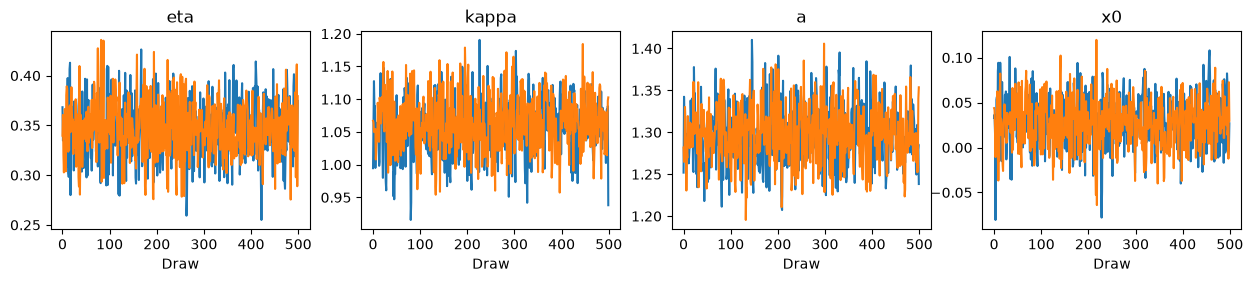

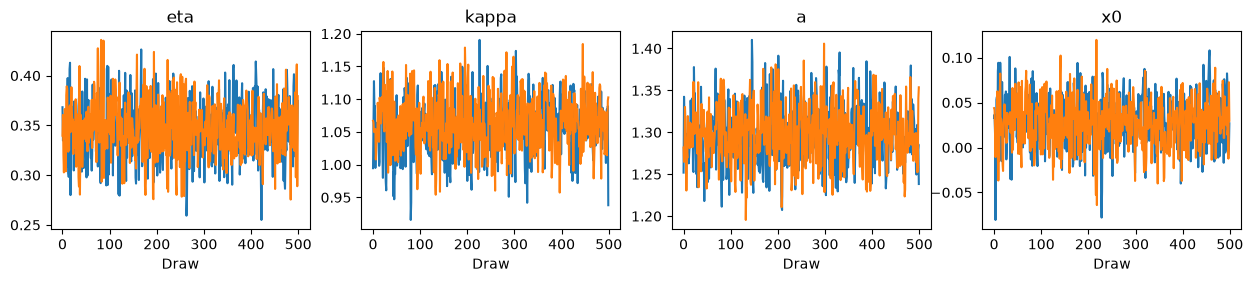

In [8]:
# ADDM_PARAMS = ["eta", "kappa", "a", "b", "x0"]
ADDM_PARAMS = ["eta", "kappa", "a", "x0"]

print(az.summary(addm_idata, var_names=ADDM_PARAMS).to_string())
fig(az.plot_trace(addm_idata, var_names=ADDM_PARAMS))

## 3. TADA — the time-averaged drift approximation

TADA replaces each trial's time-varying, gaze-dependent drift with its
**temporal average** and hands that single constant drift to a **standard DDM**.
As derived in `tada_frame`, that effective drift is linear in `A` and `B`, so the
whole approximation is a no-intercept DDM drift regression — HSSM builds it
natively, no custom `Op` needed:

$$v_{\text{TADA}} \;=\; \kappa\,A \;+\; \kappa\eta\,B
\qquad\Longrightarrow\qquad
\kappa = v_A,\quad \eta = v_B / v_A$$

Putting the DDM's boundary parameters back on the aDDM's scale: HSSM's DDM places
the bounds at `±a` (it doubles `a` internally for Navarro–Fuss) with a normalized
start `z ∈ (0, 1)`, so `a` is directly comparable and `x0 = (2z - 1) * a`.

A standard DDM has **no boundary collapse**, so this fit has no counterpart for
`b` — §4 supplies one.

In [9]:
tada_model = hssm.HSSM(
    data=tada_data,
    model="ddm",
    t=0.0,  # no non-decision time, as in the aDDM fit
    include=[
        {
            "name": "v",
            "formula": "v ~ 0 + A + B",  # no intercept: v = kappa*A + kappa*eta*B
            "link": "identity",
            "prior": {
                "A": {"name": "Normal", "mu": 0.0, "sigma": 3.0},
                "B": {"name": "Normal", "mu": 0.0, "sigma": 3.0},
            },
        }
    ],
)

t_start = time.perf_counter()
tada_idata = tada_model.sample(
    sampler="numpyro",
    draws=DRAWS,
    tune=TUNE,
    chains=CHAINS,
    cores=1,
    random_seed=SEED,
    idata_kwargs={"log_likelihood": False},
)
print(f"\nTADA (flat bound) sampling: {time.perf_counter() - t_start:.0f} s")

Model initialized successfully.
Using default initvals. 



NUTS[numpyro]: [a, z, v_A, v_B]
Running chain 1: 100%|██████████| 1000/1000 [00:06<00:00, 150.95it/s]
We recommend running at least 4 chains for robust computation of convergence diagnostics



TADA (flat bound) sampling: 9 s


       mean      sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  mcse_sd
v_A   1.164   0.056      1.1      1.3       851       850  1.00    0.0019   0.0013
v_B    0.08   0.068   -0.032     0.19      1070       845  1.00    0.0021   0.0014
a     1.258   0.037      1.2      1.3       826       661  1.01    0.0013  0.00094
z    0.5102  0.0113     0.49     0.53       895       682  1.00   0.00038  0.00026

        mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  mcse_sd
eta    0.069   0.06   -0.025     0.17      1065       802  1.00    0.0018   0.0013
kappa  1.164  0.056      1.1      1.3       851       850  1.00    0.0019   0.0013
a      1.258  0.037      1.2      1.3       826       661  1.01    0.0013  0.00094
x0     0.025  0.028    -0.02    0.072       902       682  1.00   0.00095  0.00065


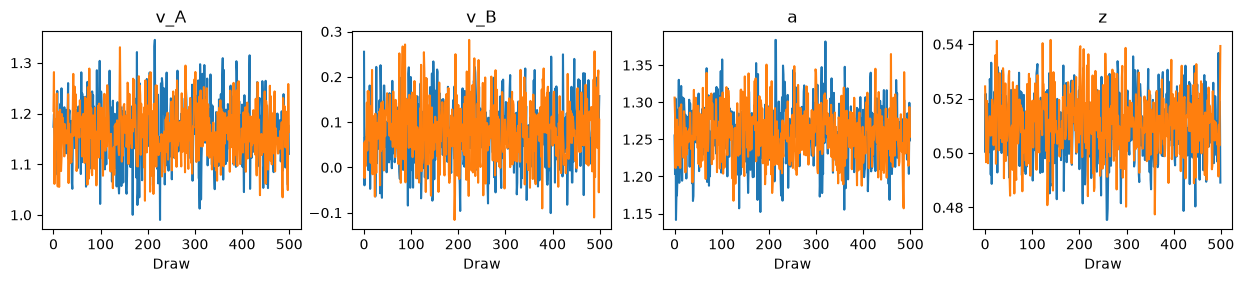

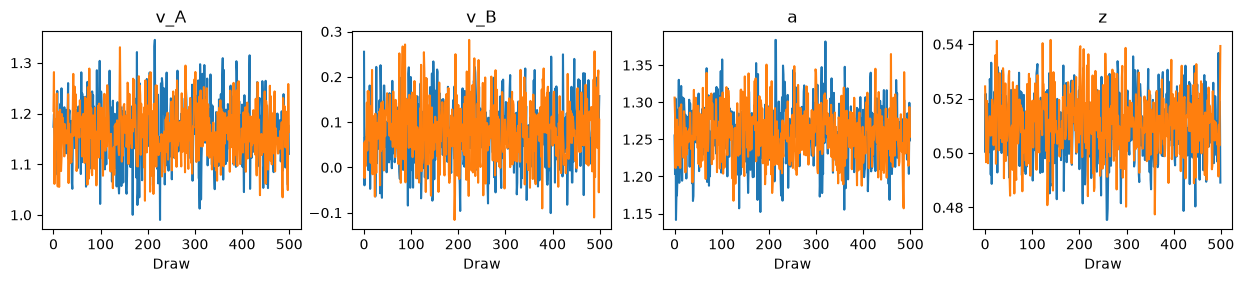

In [10]:
def to_addm_scale(idata):
    """A DDM / angle posterior, expressed in the aDDM's parameterisation.

    kappa = v_A,  eta = v_B / v_A,  a as-is (HSSM puts the DDM bounds at +-a,
    doubling `a` internally for Navarro-Fuss), and x0 = (2z - 1) * a.
    For `angle` the bound is a - t*tan(theta), so the linear collapse rate is
    b = tan(theta) -- directly comparable to the aDDM's b.
    """
    p = posterior(idata)
    out = xr.Dataset(
        {
            "eta": p["v_B"] / p["v_A"],
            "kappa": p["v_A"],
            "a": p["a"],
            "x0": (2.0 * p["z"] - 1.0) * p["a"],
        }
    )
    if "theta" in p:
        out["b"] = np.tan(p["theta"])
    return out


tada_post = to_addm_scale(tada_idata)

print(az.summary(tada_idata, var_names=["v_A", "v_B", "a", "z"]).to_string())
print()
print(az.summary(as_tree(tada_post), var_names=["eta", "kappa", "a", "x0"]).to_string())
fig(az.plot_trace(tada_idata, var_names=["v_A", "v_B", "a", "z"]))

## 4. TADA with a collapsing bound — the `angle` model

§3 changes *two* things at once relative to §2: the drift is time-averaged **and**
the bound stops collapsing. This monkey wants a strongly collapsing bound, so the
`a` comparison in §5 is partly a boundary-mismatch artifact, and `b` has no
counterpart at all.

Fix that by swapping the likelihood underneath the *same* regression: HSSM's
`angle` model is the DDM with a linearly collapsing bound `±(a - t·tan θ)`. So
this cell is §3 verbatim with `model="angle"`, and

$$b_{\text{TADA}} = \tan\theta$$

joins `kappa = v_A`, `eta = v_B / v_A`, `x0 = (2z-1)a` in `to_addm_scale`.

Two forced deviations from §3, both from `angle` being a **LAN** (a neural
likelihood) rather than an analytical one:

* `t = 0.001` instead of `0.0` — the LAN's `t` support starts at 1 ms, and HSSM
  rejects a fixed value outside a parameter's bounds. At this RT scale 1 ms is
  numerically irrelevant.
* the LAN was trained on `v ∈ [-3, 3]`, `a ∈ [0.3, 3]`, `z ∈ [0.1, 0.9]`,
  `theta ∈ [-0.1, 1.3]` (so `b` up to ≈3.6). At `kappa ≈ 1.2` the effective drift
  `kappa·A` runs past `|v| = 3` on ~4% of trials, and `z ∈ [0.1, 0.9]` confines
  `x0` to `±0.8a`. Read §5's `a`, `b`, `x0` with that in mind, and check whether
  any of them is pinned against a bound.

In [ ]:
# # Identical to the §3 model except for `model=` (and the 1 ms t, forced by the
# # LAN's support).  The collapse rate comes back out as b = tan(theta).
# tada_angle_model = hssm.HSSM(
#     data=tada_data,
#     model="angle",
#     t=0.001,  # LAN support starts at 1 ms; effectively zero at this RT scale
#     include=[
#         {
#             "name": "v",
#             "formula": "v ~ 0 + A + B",  # no intercept: v = kappa*A + kappa*eta*B
#             "link": "identity",
#             "prior": {
#                 "A": {"name": "Normal", "mu": 0.0, "sigma": 3.0},
#                 "B": {"name": "Normal", "mu": 0.0, "sigma": 3.0},
#             },
#         }
#     ],
# )

# t_start = time.perf_counter()
# tada_angle_idata = tada_angle_model.sample(
#     sampler="numpyro",
#     draws=DRAWS,
#     tune=TUNE,
#     chains=CHAINS,
#     cores=1,
#     random_seed=SEED,
#     idata_kwargs={"log_likelihood": False},
# )
# print(f"\nTADA (angle, collapsing bound) sampling: {time.perf_counter() - t_start:.0f} s")

In [ ]:
# tada_angle_post = to_addm_scale(tada_angle_idata)

# print(az.summary(tada_angle_idata, var_names=["v_A", "v_B", "a", "z", "theta"]).to_string())
# print()
# print(az.summary(as_tree(tada_angle_post), var_names=ADDM_PARAMS).to_string())
# fig(az.plot_trace(tada_angle_idata, var_names=["v_A", "v_B", "a", "z", "theta"]))

## 5. Comparison

All three fits, put on the aDDM's parameterisation (`eta, kappa, a, b, x0`).

In [13]:
PARAMS = ["eta", "kappa", "a", "x0"]

# Every fit, expressed in the aDDM's parameterisation.
fits = {
    "aDDM (exact)": posterior(addm_idata)[PARAMS],
    # "TADA (angle, collapsing)": tada_angle_post,
    "TADA (ddm, flat bound)": tada_post,  # b does not exist for a standard DDM
}
trees = {name: as_tree(ds) for name, ds in fits.items()}
COLORS = {
    "aDDM (exact)": "#1f77b4",
    # "TADA (angle, collapsing)": "#ff7f0e",
    "TADA (ddm, flat bound)": "#d62728",
}

# LAN support limits, to flag any angle parameter pinned against a bound.
LAN_BOUNDS = {"a": (0.3, 3.0), "b": (np.tan(-0.1), np.tan(1.3))}

rows = []
for p in PARAMS:
    row = {"param": p}
    for name, ds in fits.items():
        if p not in ds:
            row[name] = "--  (no collapse)"
            continue
        x = np.asarray(ds[p]).ravel()
        lo, hi = np.quantile(x, [0.03, 0.97])
        flag = ""
        if name.startswith("TADA (angle") and p in LAN_BOUNDS:
            blo, bhi = LAN_BOUNDS[p]
            if lo <= blo + 0.02 * (bhi - blo) or hi >= bhi - 0.02 * (bhi - blo):
                flag = "  <- at LAN bound"
        row[name] = f"{x.mean():7.3f}  [{lo:7.3f}, {hi:7.3f}]{flag}"
    rows.append(row)

comparison = pd.DataFrame(rows).set_index("param")
print("posterior mean  [3%, 97%]\n")
print(comparison.to_string())

print("\nconvergence (worst r_hat / smallest bulk-ESS per fit)")
for name, tree in trees.items():
    s = az.summary(tree, var_names=[p for p in PARAMS if p in fits[name]])
    r = pd.to_numeric(s["r_hat"], errors="coerce")
    e = pd.to_numeric(s["ess_bulk"], errors="coerce")
    print(f"  {name:<26s} r_hat <= {r.max():.3f}   ess_bulk >= {e.min():.0f}")

posterior mean  [3%, 97%]

                      aDDM (exact)       TADA (ddm, flat bound)
param                                                          
eta      0.346  [  0.292,   0.399]    0.069  [ -0.038,   0.188]
kappa    1.060  [  0.982,   1.140]    1.164  [  1.058,   1.269]
a        1.298  [  1.234,   1.364]    1.258  [  1.191,   1.329]
x0       0.028  [ -0.022,   0.078]    0.025  [ -0.027,   0.077]

convergence (worst r_hat / smallest bulk-ESS per fit)
  aDDM (exact)               r_hat <= 1.010   ess_bulk >= 552
  TADA (ddm, flat bound)     r_hat <= 1.010   ess_bulk >= 826


ValueError: must supply at least one object to concatenate

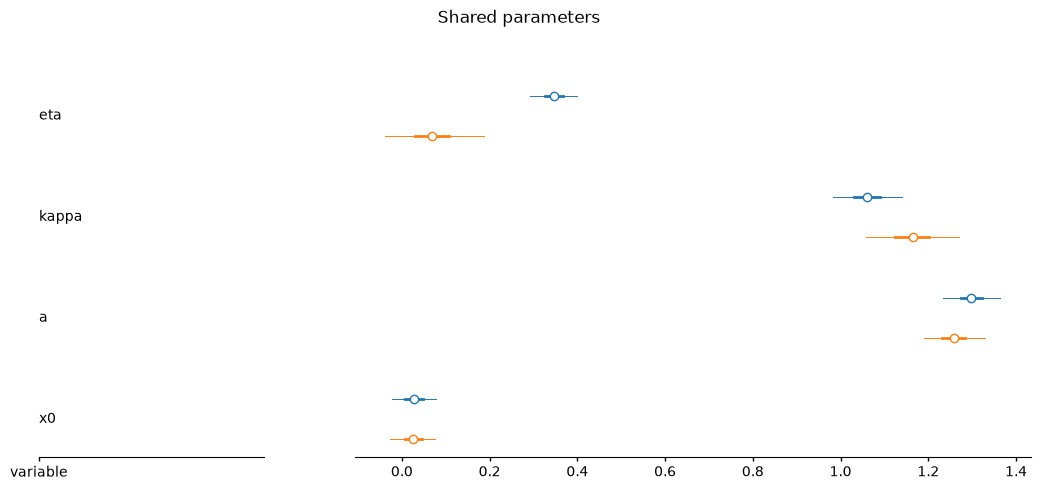

In [14]:
# Forest plot: 94% intervals side by side.  `b` only exists for the two
# collapsing-bound fits, so it gets its own panel.
fig(
    az.plot_forest(
        trees,
        var_names=["eta", "kappa", "a", "x0"],
        combined=True,
        ci_probs=(0.5, 0.94),
    )
).suptitle("Shared parameters", y=1.02)

fig(
    az.plot_forest(
        {k: v for k, v in trees.items() if "b" in fits[k]},
        var_names=["b"],
        combined=True,
        ci_probs=(0.5, 0.94),
    )
).suptitle("Boundary collapse rate b (flat-bound TADA has none)", y=1.15)
plt.gcf()

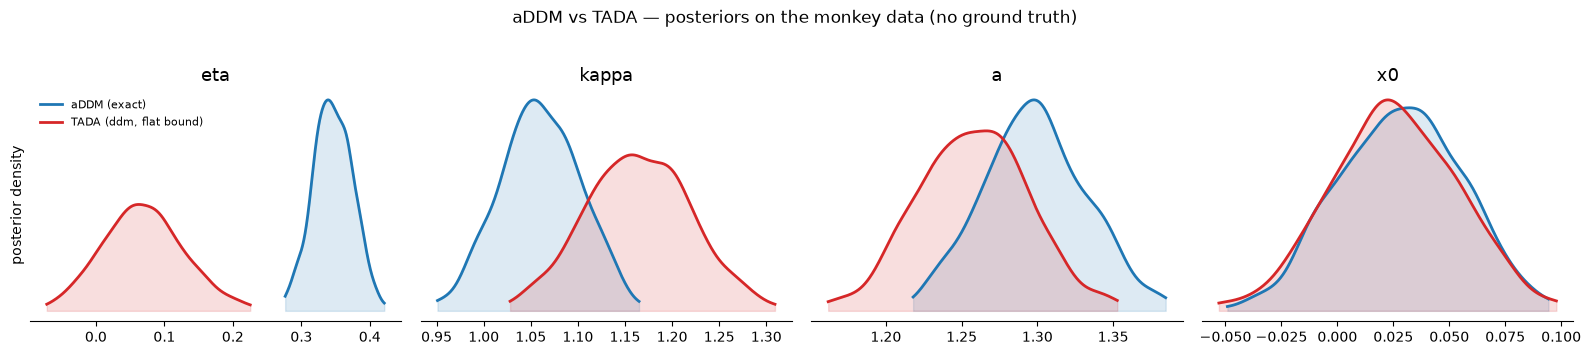

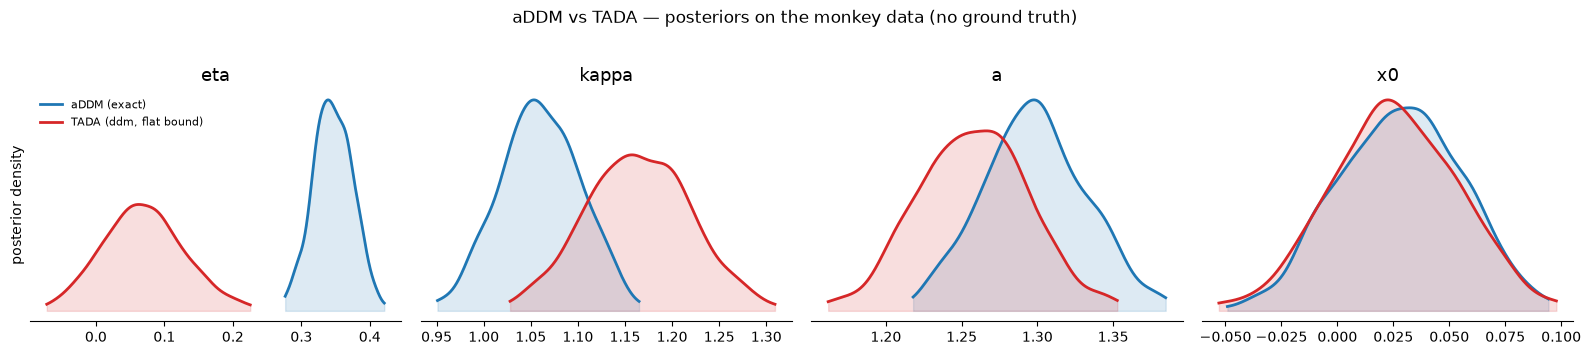

In [15]:
# Posterior densities, one panel per aDDM parameter.
from scipy.stats import gaussian_kde

_f, _axes = plt.subplots(1, len(PARAMS), figsize=(4.0 * len(PARAMS), 3.4))
for _ax, _p in zip(_axes, PARAMS):
    for _name, _ds in fits.items():
        if _p not in _ds:
            continue
        _x = np.asarray(_ds[_p]).ravel()
        # trim the ratio-induced tails of eta so the panel stays readable
        _lo, _hi = np.quantile(_x, [0.005, 0.995])
        _grid = np.linspace(_lo, _hi, 400)
        _dens = gaussian_kde(_x)(_grid)
        _ax.plot(_grid, _dens, color=COLORS[_name], lw=2, label=_name)
        _ax.fill_between(_grid, _dens, color=COLORS[_name], alpha=0.15)
    _ax.set_title(_p, fontsize=13)
    _ax.set_yticks([])
    _ax.spines[["top", "right", "left"]].set_visible(False)
_axes[0].set_ylabel("posterior density")
_axes[0].legend(fontsize=8, frameon=False)
_f.suptitle("aDDM vs TADA — posteriors on the monkey data (no ground truth)", y=1.03)
_f.tight_layout()
_f

## 6. Posterior predictive checks, split by value difference × gaze

§5 compares where the parameters land. This asks the more useful question: which
likelihood actually reproduces the data. The layout is the one from
`attentional_ddm.ipynb` ("Adding the gaze-to-optimal split") — value difference
`r1 - r2` across the columns, gaze to the higher-value option down the rows,
predicted vs observed drawn by HSSM's own renderer (`_plot_predictive_2D`), so
the styling and legend match `model.plot_predictive`.

Run `plot_ppc_value_gaze` once per fit and compare by eye. Watch the
`|value_diff| = 1` columns and the two gaze rows: an aDDM effect that TADA's
time-averaging throws away should show up as the *gaze rows failing to separate*,
not as a uniform miss.

Three things to know about the implementation:

* **Every predicted draw is re-classified on its own simulated rt.** The last
  observed fixation is right-censored at the response, so its duration — and
  therefore the gaze proportion — moves with rt. That is why this cannot go
  through `plot_predictive`'s `col`/`row` faceting, which classifies each trial
  once by its *observed* covariates.
* **The gaze covariates come from `data`, not `model.data`.** The two TADA frames
  only carry `rt, response, A, B`, so they cannot supply `sacc_array`, `d`,
  `flag`. All three models were fit to the same 587 trials in the same order, so
  `obs_n` indexes the aDDM frame either way — and using one design frame for all
  three is what makes the figures comparable.
* **`sample_ppc` replaces `model.sample_posterior_predictive`** (compat shim #3).
  HSSM's method is written against arviz < 1.0 and hits two DataTree problems:
  `idata.groups()` raises `TypeError: 'tuple' object is not callable` (`groups`
  is a property, not a method), and — worse, because it is silent —
  `setattr(idata_copy, "posterior", subsample)` sets a shadow Python attribute
  instead of replacing the group, so `draws=` is quietly ignored and the
  predictive runs over *every* posterior draw. `sample_ppc` does the same job
  through `__setitem__`, keeping HSSM's 10-draw chunking.

In [16]:
from hssm.plotting.predictive import _plot_predictive_2D
from hssm.plotting.utils import _get_plotting_df


def sample_ppc(model, idata, draws=100, chunk=10):
    """DataTree-safe stand-in for `HSSMBase.sample_posterior_predictive(kind="response")`.

    Compat shim #3 (see cell 1).  HSSM's own method is written against
    arviz < 1.0's InferenceData and breaks on xarray's DataTree in two ways:

    * `idata.groups()` -- `groups` is a *property* returning a tuple of paths,
      so calling it raises `TypeError: 'tuple' object is not callable`;
    * `setattr(idata_copy, "posterior", subsample)` -- silently sets a shadow
      Python attribute instead of replacing the group, so the `draws` argument
      is quietly ignored and the predictive runs over *every* posterior draw.

    The second one is the dangerous one: no error, just a much slower run over
    the wrong draws.  This does the same job with `__setitem__`, keeping HSSM's
    chunking (10 draws at a time) to bound simulator memory.
    """
    if "posterior_predictive" in idata.children:
        del idata["posterior_predictive"]
    if model._check_extra_fields():
        model._update_extra_fields()  # for aDDM this also re-pushes the RV fixations

    post = idata["posterior"].dataset
    n_draws = post.sizes["draw"]
    sel = np.arange(min(int(draws), n_draws)) if np.isscalar(draws) else np.asarray(draws)

    parts = []
    for block in np.array_split(sel, max(1, len(sel) // max(1, chunk))):
        scratch = idata.copy()
        if "posterior_predictive" in scratch.children:
            del scratch["posterior_predictive"]
        scratch["posterior"] = xr.DataTree(post.isel(draw=block))
        model.model.predict(
            scratch, kind="response", data=None, inplace=True,
            include_group_specific=True,
        )
        parts.append(scratch["posterior_predictive"].dataset)

    idata["posterior_predictive"] = xr.DataTree(xr.concat(parts, dim="draw"))
    return idata


def _gaze_prop_item1(rt, sacc, d, flag):
    """Gaze proportion to item 1, evaluated at an ARBITRARY rt per row.

    Same weighting as `gaze_fraction_item1`, but `rt` varies row by row, so it can
    be applied to each predicted draw's *own* simulated rt -- which is the whole
    point: the last observed fixation is right-censored at the response, so its
    duration, and hence the gaze proportion, moves with rt.
    """
    n, max_d = sacc.shape
    col = np.arange(max_d)
    active = col[None, :] < d[:, None]
    nxt = np.full((n, max_d), np.inf)
    nxt[:, :-1] = np.where(active[:, 1:], sacc[:, 1:], np.inf)
    rt_col = rt[:, None]
    dur = np.clip(np.minimum(nxt, rt_col) - np.minimum(sacc, rt_col), 0.0, None) * active
    on1 = ((col[None, :] % 2) == flag[:, None]) & active
    total = dur.sum(1)
    out = np.full(n, np.nan)
    ok = (rt > 0) & (total > 0)
    out[ok] = (dur * on1).sum(1)[ok] / total[ok]
    return out


def plot_ppc_value_gaze(
    model,
    idata,
    title,
    draws=100,
    design=None,
    x_range=(-2.5, 2.5),
    bins=25,
    max_abs_diff=3,
    do_sample=True,
    grid_kwargs=None,
):
    """PPC faceted by value difference (columns) x gaze to the higher-value item (rows).

    This is the `ppc_tests` layout reproduced in `attentional_ddm.ipynb`: the draws
    come from HSSM's posterior predictive (`_get_plotting_df`) and the panels are
    drawn by HSSM's own line renderer (`_plot_predictive_2D`), so the styling and
    legend are identical to `model.plot_predictive`.

    The gaze split cannot go through `plot_predictive`'s `col`/`row` faceting:
    those classify each *trial* once by its observed covariates, whereas
    gaze-to-higher depends on each *draw's* simulated rt.  So every predicted draw
    is re-classified on its own rt here.

    Parameters
    ----------
    model, idata
        A fitted HSSM model and its inference data.  Works for all three fits.
    design
        Frame supplying the per-trial gaze covariates (`sacc_array, d, flag, r1,
        r2`).  Defaults to the aDDM frame `data`.  The TADA frames drop those
        columns, so they cannot supply them -- but all three models were fit to the
        same 587 trials in the same order, so `obs_n` indexes `data` either way.
    bins
        Histogram bins per panel.  HSSM's default of 100 is far too many here:
        ~587 trials over 12 panels is ~50 observed RTs per cell, which turns the
        observed line into noise.
    do_sample
        Draw a fresh posterior predictive first.  Set False to reuse the draws
        already attached to `idata`.
    """
    if do_sample:
        sample_ppc(model, idata, draws=draws)

    pp = _get_plotting_df(
        idata,
        model.data,
        extra_dims=None,
        n_samples=None,
        response_str=model.response_str,
    )

    design = (data if design is None else design).reset_index(drop=True)
    obs_n = pp.index.get_level_values("obs_n").to_numpy()
    rt = pp["rt"].to_numpy(dtype=float)  # each row's own rt (predicted or observed)
    sacc = np.stack([np.asarray(s, float) for s in design["sacc_array"]])[obs_n]
    d_obs = design["d"].to_numpy()[obs_n]
    flag = design["flag"].to_numpy()[obs_n]
    r1 = design["r1"].to_numpy()[obs_n]
    r2 = design["r2"].to_numpy()[obs_n]

    prop1 = _gaze_prop_item1(rt, sacc, d_obs, flag)
    prop_opt = np.where(r1 > r2, prop1, 1.0 - prop1)  # gaze to the HIGHER-value item

    # Facet labels.  r1 == r2 has no higher option, so the split is undefined and
    # those trials are dropped; |diff| = 4 is merged into 3 to keep the grid compact.
    # Row labels are kept short -- margin_titles writes them sideways in the margin.
    pp = pp.assign(
        value_diff=np.clip(np.rint(r1 - r2).astype(int), -max_abs_diff, max_abs_diff),
        gaze_to_higher=np.where(prop_opt > 0.5, "gaze > 0.5", "gaze <= 0.5"),
    )
    pp = pp[(pp["value_diff"].to_numpy() != 0) & np.isfinite(prop_opt)]

    # Sign rt by choice (works for both -1/1 and 0/1 codings), then hand off to HSSM.
    pp = pp.assign(rt=pp["rt"] * np.where(pp["response"].to_numpy() > 0, 1.0, -1.0))

    g = _plot_predictive_2D(
        pp,
        row="gaze_to_higher",
        col="value_diff",
        bins=bins,
        x_range=x_range,
        title=(
            f"{title} — columns: value difference (r1 - r2);  "
            "rows: gaze proportion to the higher-value item"
        ),
        grid_kwargs={
            "height": 2.4,
            "aspect": 0.95,
            "margin_titles": True,
            **(grid_kwargs or {}),
        },
    )
    return g

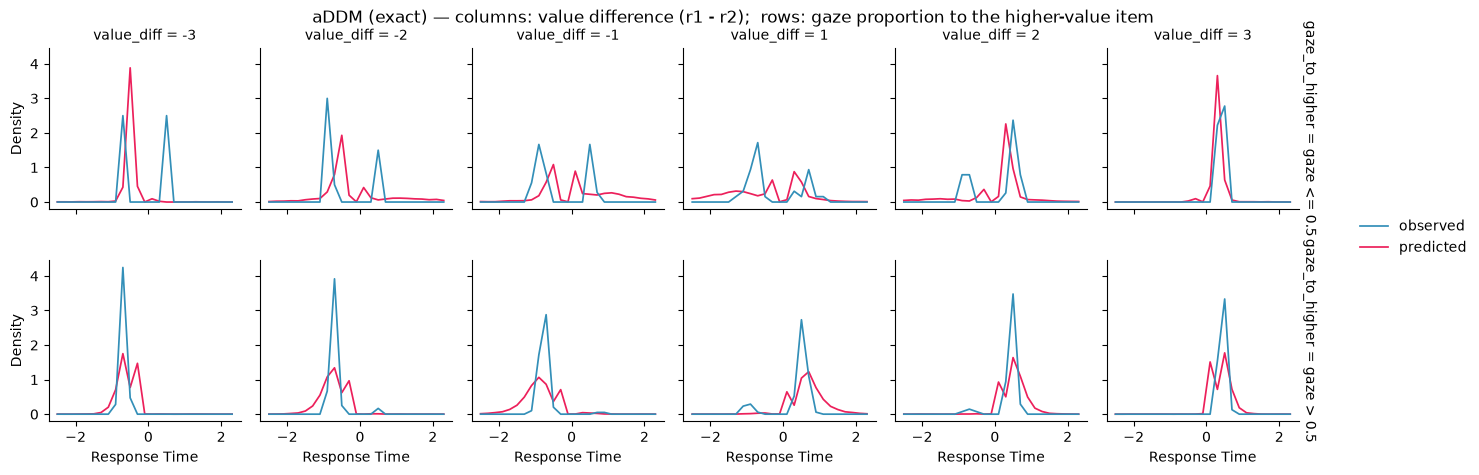

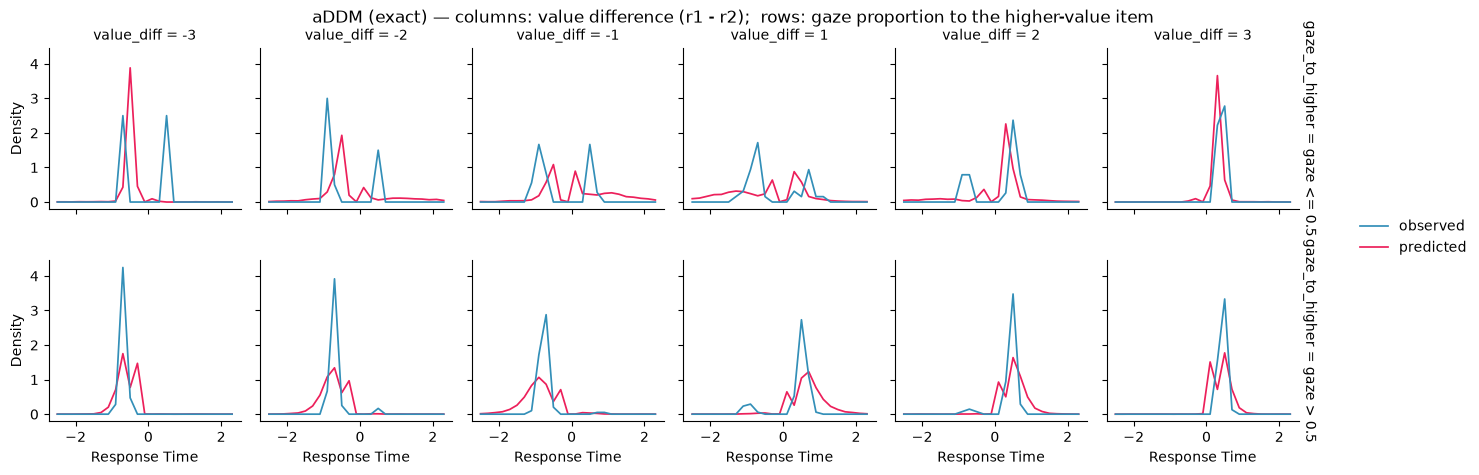

In [17]:
plot_ppc_value_gaze(addm_model, addm_idata, "aDDM (exact)").figure

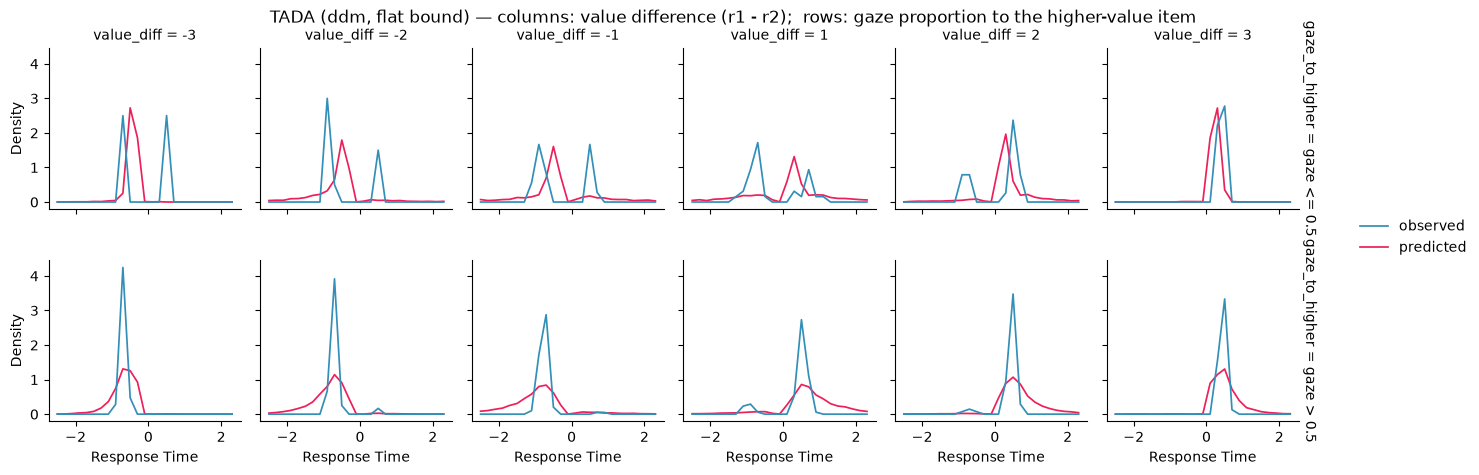

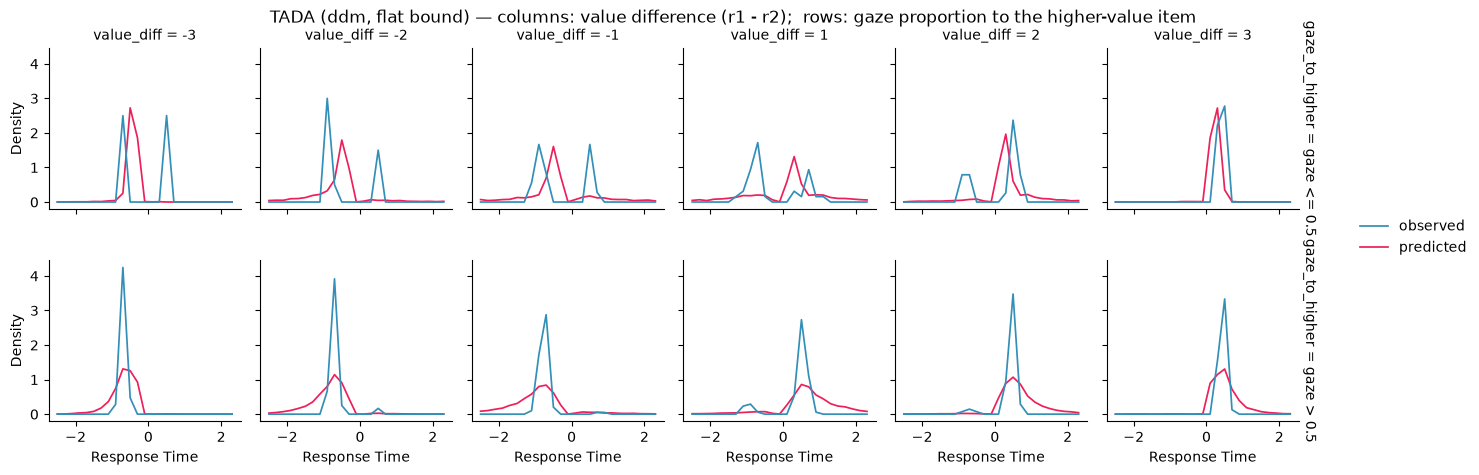

In [21]:
plot_ppc_value_gaze(tada_model, tada_idata, "TADA (ddm, flat bound)").figure

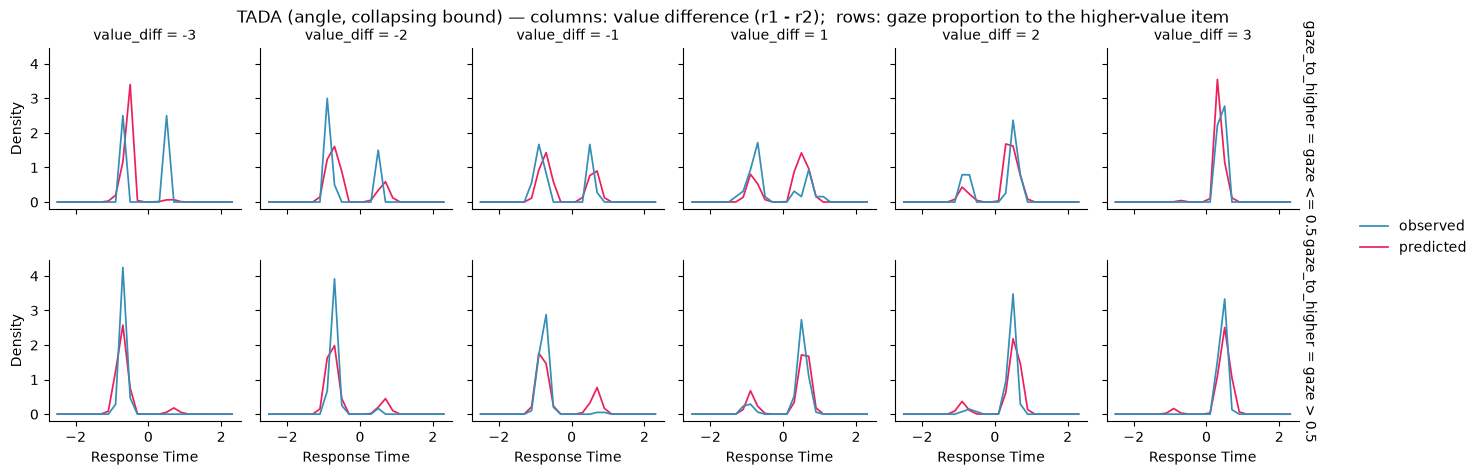

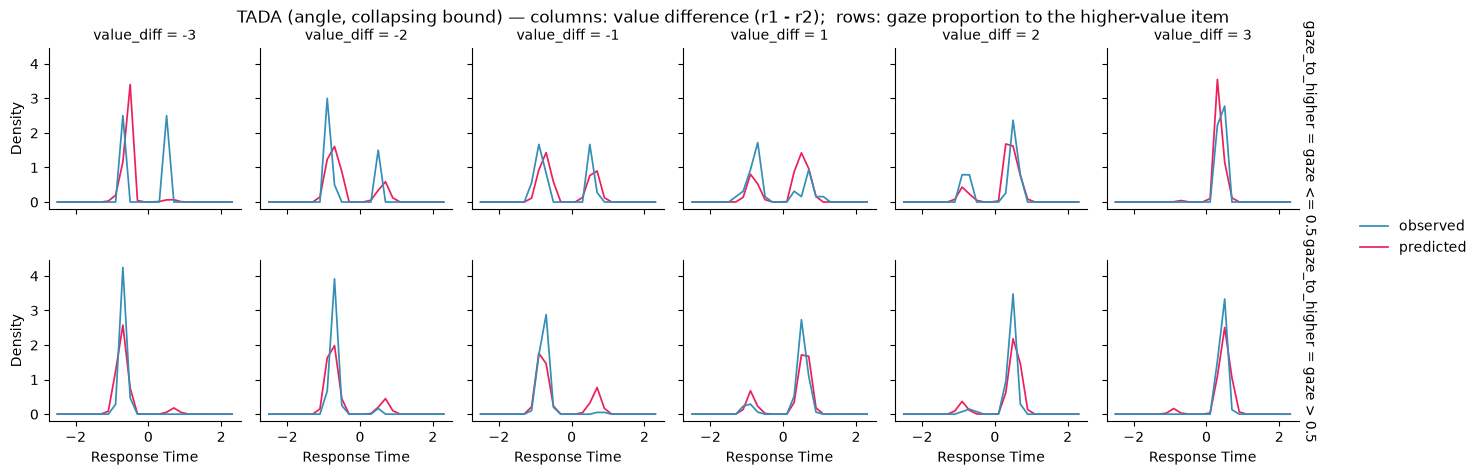

In [25]:
plot_ppc_value_gaze(tada_angle_model, tada_angle_idata, "TADA (angle, collapsing bound)").figure

## 7. How to read this — and what it is *not*

**These are posterior comparisons, not a recovery study.** The monkey data has no
ground truth, so nothing here says which estimate is *correct*; it says how far
apart the likelihoods land on the same trials. The three fits are laid out so the
gap can be attributed:

| fit | drift | bound | likelihood | tells you |
|---|---|---|---|---|
| aDDM (exact) | gaze-alternating, per stage | collapsing | exact FPT | the reference |
| TADA (angle, collapsing) | time-averaged | collapsing | LAN | **the cost of time-averaging** with the collapse still in the model |
| TADA (ddm, flat bound) | time-averaged | flat | analytical | the approximation as the paper states it — a standard DDM, which also gives up the collapse |

So `aDDM` → `TADA (angle)` isolates the time-averaging that the TADA paper is
about; `TADA (angle)` → `TADA (ddm)` adds the boundary mismatch on top. §6 is the
part that can actually adjudicate between them: parameters can differ for
uninteresting reasons, but only one of these fits has to reproduce the observed
RT distributions *within* each gaze × value cell.

**Caveats.**

* The two TADA rows differ from each other in *likelihood family* as well as
  boundary: `angle` is a trained neural likelihood, `ddm` is Navarro–Fuss. A
  small `a`/`x0` shift between them is expected from LAN approximation error
  alone, before any modelling difference.
* `angle`'s LAN support (`v ∈ [-3, 3]`, `a ∈ [0.3, 3]`, `z ∈ [0.1, 0.9]`,
  `theta ∈ [-0.1, 1.3]`) is narrower than this problem needs — ~4% of trials have
  `|kappa·A| > 3`, and `z ∈ [0.1, 0.9]` caps `|x0|` at `0.8a`. The §5 table flags
  any `a`/`b` interval that reaches a LAN bound; if one does, treat that number as
  censored rather than estimated.
* `eta` is weakly identified here: the monkey's gaze fractions sit close to
  balanced (`g1` concentrated near 0.5), exactly the regime where the `A` and `B`
  regressors are hard to separate. Read `eta` intervals, not points.
* In both TADA fits `eta = v_B / v_A` is a *ratio*, so its posterior is
  heavy-tailed and not confined to `[0, 1]` the way the aDDM's `eta` is. That is a
  real difference in parameterisation, not a sampling artifact.
* `x0` and `a` are on the aDDM's scale throughout (bounds at `±a`, start in
  `(-a, a)`); both TADA fits were converted with `x0 = (2z - 1) * a`.
* Stock `aDDMConfig` caps `a` and `b` at 3.0; those were widened in §2. Check the
  §5 table for any aDDM parameter sitting on a bound too.
* Only the aDDM's posterior predictive is *gaze-conditioned* (the Mode-2 handshake
  re-simulates against each trial's observed fixation sequence). The two TADA
  fits know nothing about gaze at draw time — their predicted RTs are then
  classified by the observed gaze schedule. That asymmetry is inherent to the
  approximation, not an artifact of the plotting.

**If you want an actual recovery study**, simulate from `hssm.aDDM` at the §2
posterior mean *conditioned on this monkey's own fixation design* (the `Simulator`
"Mode 2" handshake in `attentional_ddm.ipynb` §2), then refit all three models to
the synthetic data. Ground truth is then known, and the TADA paper's headline
prediction — that `eta` is underestimated — becomes directly testable.